### Implementation of Transfer Entropy

##### Schreiber (2000): "Measuring Information Transfer" (Tent Map Example)

Author: Phoebe Kuang

Date: Apr 27, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

--- 

#### Part 1: Data Generation (Tent Map)

We use a 1D spatial lattice of $M$ chaotic tent maps, unidirectionally coupled from left to right ($m-1 \rightarrow m$) using the relation:

$$x_{n+1}^m = f\big(\epsilon x_n^{m-1} + (1-\epsilon)x_n^m\big)$$

where $f(x)$ is the tent map and $\epsilon$ is the coupling strength. We implement *periodic boundary conditions* ($x_n^0 \equiv x_n^M$).

In [2]:
def generate_tent_map_data(M, N, N_trans, epsilon, seed=None):
    """
    Generates time series data for a 1D lattice of unidirectionally coupled tent maps.
    
    Parameters:
    M (int): Number of sites in the lattice.
    N (int): Number of time iterations to keep.
    N_trans (int): Number of transient iterations to discard.
    epsilon (float): Coupling strength.
    
    Returns:
    numpy.ndarray: An array of shape (N, M) containing the continuous states.
    """
    # Total iterations to run
    total_steps = N + N_trans
    
    # Initialize the lattice with random values between 0 and 1
    # Rows = time steps, Columns = sites
    if seed is not None: # Reproducibility & 10 runs for Reproduce Figure
        np.random.seed(seed)
    
    X = np.zeros((total_steps, M))
    X[0] = np.random.uniform(0, 1, M)
    
    # Run the coupled map lattice
    for n in range(total_steps - 1):
        # np.roll(X[n], shift=1) shifts the array to the right by 1
        # This implements the periodic boundary condition
        # The site at index 0 will take the value from the last index (M-1).
        left_neighbor = np.roll(X[n], shift=1)
        
        # Calculate the coupled input
        Z = epsilon * left_neighbor + (1 - epsilon) * X[n]
        
        # Apply the tent map function f(Z)
        # 2 * Z if Z < 0.5, else 2 - 2 * Z
        X[n+1] = np.where(Z < 0.5, 2 * Z, 2 - 2 * Z)
        
    # Discard the transient part and return only the last N iterations
    return X[N_trans:]

In [3]:
def visualize_tent_map(data, epsilon, max_time_steps=100):
    """
    Visualizes a slice of the continuous spatio-temporal data.
    """
    # Slice the data for a clean & reasonablevisualization
    plot_data = data[:max_time_steps, :]
    
    plt.figure(figsize=(7, 5))
    # imshow is perfect for a grid of continuous values. 
    # 'viridis' gives a nice continuous color gradient from 0 to 1.
    plt.imshow(plot_data, aspect='auto', cmap='viridis', interpolation='none')
    
    plt.colorbar(label='State Value [0, 1]')
    plt.xlabel('Site Index (m)')
    plt.ylabel('Time Step (n)')
    plt.tight_layout()
    plt.show()


In [4]:
# Parameters (Same as Schreiber's paper setup)
M = 100
N = 100000
N_trans = 100000

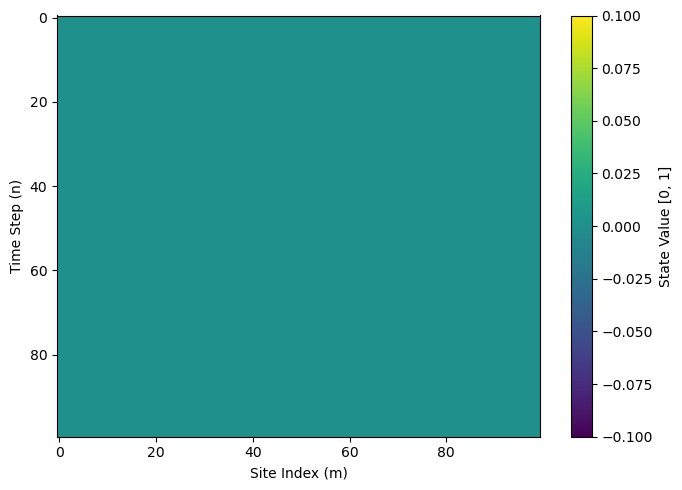

In [5]:
# Zero coupling
epsilon_zero = 0.0
data_zero = generate_tent_map_data(M, N, N_trans, epsilon_zero)
visualize_tent_map(data_zero, epsilon_zero, max_time_steps=100)

Notes: There's a precision issue for $\epsilon = 0$, so we use $\epsilon = 1e^{-15} \to 0$ to explore the behavior of epsilon, including (approxmiate) zero coupling case.

In [6]:
def visualize_tent_map_grid(epsilons, M=100, max_steps=100):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes_flat = axes.flatten()
    
    im = None
    
    for idx, eps in enumerate(epsilons):
        data = generate_tent_map_data(M=M, N=max_steps, N_trans=100000, epsilon=eps)
        
        ax = axes_flat[idx]
        im = ax.imshow(data, aspect='auto', cmap='viridis', interpolation='none', vmin=0, vmax=1)
        
        ax.text(0.05, 0.95, f'$\\epsilon = {eps}$', transform=ax.transAxes, 
                color='white', fontsize=14, fontweight='bold', va='top',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
        
        ax.set_xlabel('Site Index (m)')
        ax.set_ylabel('Time Step (n)')
    
    fig.tight_layout()
    fig.colorbar(im, ax=axes.ravel().tolist(), label='State Value [0, 1]', fraction=0.046, pad=0.04)
    plt.show()

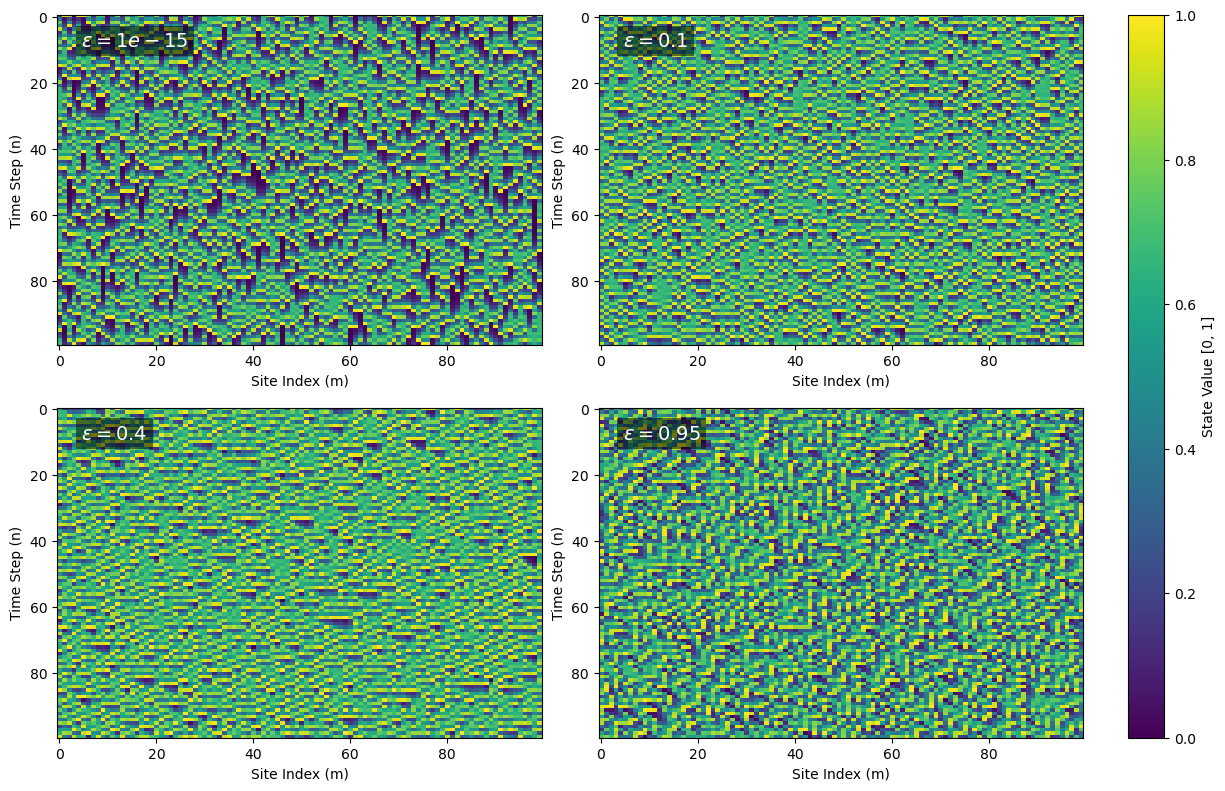

In [7]:
epsilons = [1e-15, 0.1, 0.4, 0.95]
visualize_tent_map_grid(epsilons, M=100, max_steps=100)

---

#### Part 2: Transfer Entropy Implementation

We follow Schreiber's paper to coarse-grain the continuous data into a binary partition:
* State **0**: $x < 0.5$
* State **1**: $x \ge 0.5$

Assuming a Markov process of order one ($k=l=1$), the Transfer Entropy from site $m-1$ to $m$ is defined as:

$$T_{m-1 \rightarrow m} = \sum p(i_{n+1}^m, i_n^m, i_n^{m-1}) \log_2 \frac{p(i_{n+1}^m \mid i_n^m, i_n^{m-1})}{p(i_{n+1}^m \mid i_n^m)}$$

We calculate these empirical probabilities by counting the frequencies of the dynamic transitions across the entire $N \times M$ lattice.

In [8]:
def discretize_data(X, threshold=0.5):
    """
    Converts continuous state data into a binary partition.
    """
    # Returns an integer array of 0s and 1s
    return (X >= threshold).astype(int)

In [9]:
def compute_transfer_entropy(source_series, destination_series):
    """
    Computes the Transfer Entropy from a source time series (m-1) to a destination 
    time series (m) using a Markov order of k=l=1.
    
    Parameters:
    source_series (np.array): The 1D array of the independent variable (e.g., site m-1)
    destination_series (np.array): The 1D array of the dependent variable (e.g., site m)
    
    Returns:
    float: The calculated transfer entropy in bits.
    """
    # Step 1: Discretize both continuous series
    i_series = discretize_data(destination_series)
    j_series = discretize_data(source_series)
    
    N = len(i_series)
    num_transitions = N - 1
    
    # Step 2: Initialize counters for the 8 possible 3D states (a, b, c)
    # i_n1 = destination future (n+1)
    # i_n = destination past (n)
    # j_n = source past (n)
    counts_3d = {}
    for i_n1 in [0, 1]:
        for i_n in [0, 1]:
            for j_n in [0, 1]:
                counts_3d[(i_n1, i_n, j_n)] = 0
                
    # Step 3: Count the frequencies of each transition state
    for n in range(num_transitions):
        i_n1 = i_series[n+1]
        i_n = i_series[n]
        j_n = j_series[n]
        counts_3d[(i_n1, i_n, j_n)] += 1
    
    
    # Step 4: Compute the marginal counts
    counts_2d_past = {(0,0): 0, (0,1): 0, (1,0): 0, (1,1): 0}   
    counts_2d_trans = {(0,0): 0, (0,1): 0, (1,0): 0, (1,1): 0}  
    counts_1d_past = {0: 0, 1: 0}                               
    
    for (i_n1, i_n, j_n), count in counts_3d.items():
        counts_2d_past[(i_n, j_n)] += count
        counts_2d_trans[(i_n1, i_n)] += count
        counts_1d_past[i_n] += count
        
    # Step 5: Calculate Transfer Entropy using Eq. (4) from Schreiber's paper
    te_value = 0.0
    
    for (i_n1, i_n, j_n), joint_count in counts_3d.items():
        if joint_count > 0:
            joint_prob = joint_count / num_transitions
            
            # Inside the log, we use counts (the denominators cancel out and we can avoid precision issues)
            numerator_counts = joint_count * counts_1d_past[i_n]
            denominator_counts = counts_2d_past[(i_n, j_n)] * counts_2d_trans[(i_n1, i_n)]
            
            term = joint_prob * np.log2(numerator_counts / denominator_counts)
            te_value += term
            
    return te_value

---

#### Part 3: Reproducing the Tent Map Results

We recreate Schreiber's numerical experiment (Figure 1). We simulate a 100-site lattice for $10^5$ iterations across a range of coupling strengths ($\epsilon \in [1e-15, 0.05]$). 

For each $\epsilon$, we compute the spatially averaged TE in two directions:
Forward ($T_{m-1 \rightarrow m}$) \& Backward ($T_{m \rightarrow m-1}$)

Notes: Because calculating the joint probabilities across $10^5$ steps for 100 sites and 25 different $\epsilon$ values is computationally expensive, we utilize `joblib` to parallelize the simulations across all available CPU cores.

In [10]:
def compute_lattice_transfer_entropy(data, direction='forward'):
    """
    Computes the spatially averaged Transfer Entropy across a 1D lattice.
    
    Parameters:
    data (np.array): The (N, M) matrix of time series data.
    direction (str): 'forward' computes T_{m-1 -> m}. 'backward' computes T_{m -> m-1}.
    
    Returns:
    float: The spatially averaged Transfer Entropy in bits.
    """
    N, M = data.shape
    te_sum = 0.0
    
    for m in range(M):
        # Apply periodic boundary conditions using modulo
        site_m = data[:, m]
        site_m_minus_1 = data[:, (m - 1) % M]
        
        if direction == 'forward':
            # Physical direction: Does (m-1) predict (m)?
            source = site_m_minus_1
            destination = site_m
        elif direction == 'backward':
            # Non-physical direction: Does (m) predict (m-1)?
            source = site_m
            destination = site_m_minus_1
            
        te_sum += compute_transfer_entropy(source_series=source, destination_series=destination)
        
    return te_sum / M

def run_single_epsilon_simulation(epsilon, M=100, N=100000, N_trans=100000, seed=None):
    """
    Generate data and compute both TE directions for a single epsilon.
    Use joblib parallelization.
    """

    # Generate data
    data = generate_tent_map_data(M=M, N=N, N_trans=N_trans, epsilon=epsilon, seed=seed)
    
    # Compute spatially averaged TE in both directions
    te_forward = compute_lattice_transfer_entropy(data, direction='forward')
    te_backward = compute_lattice_transfer_entropy(data, direction='backward')
    
    return epsilon, te_forward, te_backward

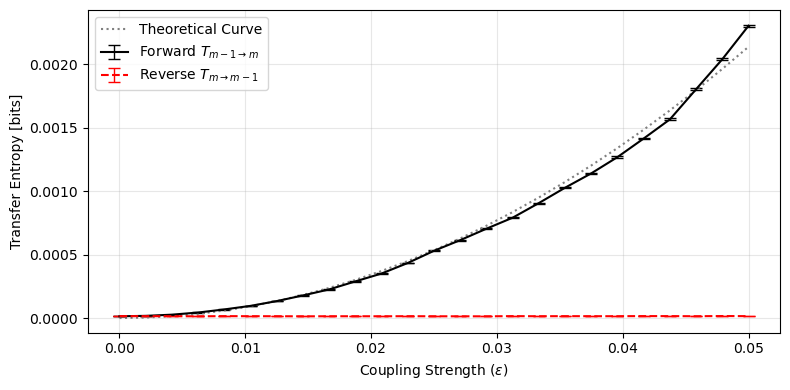

In [11]:
# Success Case: Reproduce Figure 1 from Schreiber's paper

# Parameters (Same as Schreiber's paper setup)
M = 100
N = 100000
N_trans = 100000
epsilons = np.linspace(1e-15, 0.05, 25)
num_runs = 10  # 10 independent runs per epsilon

# Create a list of all tasks: (epsilon, seed)
tasks = [(eps, run_idx) for eps in epsilons for run_idx in range(num_runs)]


# Execute in parallel
results = Parallel(n_jobs=-1)(
    delayed(run_single_epsilon_simulation)(eps, seed=r) for eps, r in tasks
)

# Reshape the flat results list into matrices of shape (25 epsilons, 10 runs)
# res[1] is te_forward, res[2] is te_backward
fwd_results = np.array([res[1] for res in results]).reshape(len(epsilons), num_runs)
bwd_results = np.array([res[2] for res in results]).reshape(len(epsilons), num_runs)

# Calculate Mean and Standard Error of the Mean
fwd_mean = fwd_results.mean(axis=1)
fwd_err = fwd_results.std(axis=1) / np.sqrt(num_runs)

bwd_mean = bwd_results.mean(axis=1)
bwd_err = bwd_results.std(axis=1) / np.sqrt(num_runs)

# Plotting Transfer Entropy vs. Coupling Strength with Error Bars
plt.figure(figsize=(8, 4))
# Plot the m-1 -> m direction
plt.errorbar(epsilons, fwd_mean, yerr=fwd_err, fmt='k-', capsize=4, elinewidth=1, label=r'Forward $T_{m-1 \rightarrow m}$')
# Plot the m -> m-1 direction
plt.errorbar(epsilons, bwd_mean, yerr=bwd_err, fmt='r--', capsize=4, elinewidth=1, label=r'Reverse $T_{m \rightarrow m-1}$')
# Add Schreiber's theoretical fit for comparison
# T = (alpha^2 * eps^2) / ln(2) where alpha approx 0.77
theoretical_te = ((0.77 * np.array(epsilons))**2) / np.log(2)
plt.plot(epsilons, theoretical_te, 'gray', linestyle=':', label='Theoretical Curve')

plt.xlabel(r'Coupling Strength ($\epsilon$)')
plt.ylabel('Transfer Entropy [bits]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

#### Part 4: Failure Cases

##### Part 4a: Failure Case - Data Deficiency

Transfer Entropy (TE) is a non-parametric, information-theoretic metric. That is, TE requires constructing empirical probability distributions from massive amounts of data. In this test, we replicate the same conditions of the tent map lattice ($\epsilon \in [1e-15, 0.05]$) but drastically reduce the time series length from $N = 100,000$ to $N = 100$. We expect the TE will fail to isolate the causal signal.

To better understand this, we fix the coupling strength at $\epsilon = 0.05$ (where true forward TE $\approx 0.002$ bits and reverse TE $= 0$ bits) and vary the number of observations $N$. 

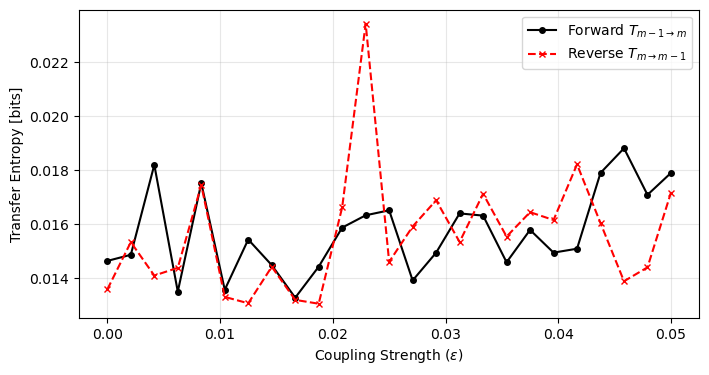

In [12]:
# Test 1: Data Deficiency
epsilons_deficient= np.linspace(1e-15, 0.05, 25)

results_deficient = Parallel(n_jobs=-1)(
    delayed(run_single_epsilon_simulation)(eps, M=100, N=100, N_trans=100000) for eps in epsilons_deficient
)

eps_deficient, fwd_deficient, bwd_deficient = zip(*results_deficient)

plt.figure(figsize=(8, 4))
plt.plot(eps_deficient, fwd_deficient, 'k-o', markersize=4, label=r'Forward $T_{m-1 \rightarrow m}$')
plt.plot(eps_deficient, bwd_deficient, 'r--x', markersize=4, label=r'Reverse $T_{m \rightarrow m-1}$')
plt.xlabel(r'Coupling Strength ($\epsilon$)')
plt.ylabel('Transfer Entropy [bits]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

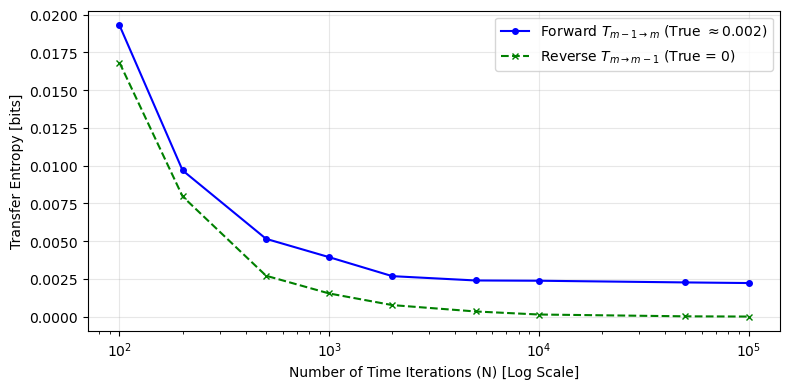

In [13]:
# Fix an epsilon
fixed_eps = 0.05

# Logarithmic scaling of N from 100 to 100,000
N_values = [100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000]

results_n = Parallel(n_jobs=-1)(
    delayed(run_single_epsilon_simulation)(fixed_eps, M=100, N=n, N_trans=100000, seed=25) for n in N_values
)

_, fwd_n, bwd_n = zip(*results_n)

plt.figure(figsize=(8, 4))
plt.plot(N_values, fwd_n, 'b-o', markersize=4, label=r'Forward $T_{m-1 \rightarrow m}$ (True $\approx 0.002$)')
plt.plot(N_values, bwd_n, 'g--x', markersize=4, label=r'Reverse $T_{m \rightarrow m-1}$ (True = 0)')

plt.xscale('log')  # Log scale to see clear convergence
plt.xlabel('Number of Time Iterations (N) [Log Scale]')
plt.ylabel('Transfer Entropy [bits]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Part 4b: Synchronization

Another limitation of Transfer Entropy occurs under strong coupling regimes. However, if the coupling strength $\epsilon$ is too strong, the interacting sites undergo generalized synchronization and their trajectories align. In this case, the past state provides no additional predictive power beyond what is already contained in the destination's own history. In this test, we expand the coupling range to $\epsilon \in [1e-15, 1.0]$. We expect the TE to peak and then drop significantly (eventually to 0) as the systems synchronize, despite causality being at its maximum.

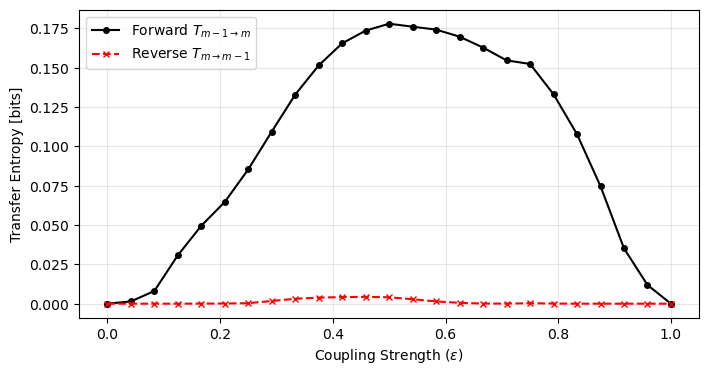

In [14]:
# Test 2: The Synchronization Paradox
# We can reduce N slightly to 20,000 just to save time, the effect is so strong it doesn't need 100k
epsilons_sync = np.linspace(1e-15, 1.0, 25)

results_sync = Parallel(n_jobs=-1)(
    delayed(run_single_epsilon_simulation)(eps, M=100, N=50000, N_trans=100000) for eps in epsilons_sync
)

eps_sync, fwd_sync, bwd_sync = zip(*results_sync)

plt.figure(figsize=(8, 4))
plt.plot(eps_sync, fwd_sync, 'k-o', markersize=4, label=r'Forward $T_{m-1 \rightarrow m}$')
plt.plot(eps_sync, bwd_sync, 'r--x', markersize=4, label=r'Reverse $T_{m \rightarrow m-1}$')
plt.xlabel(r'Coupling Strength ($\epsilon$)')
plt.ylabel('Transfer Entropy [bits]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()